# 1차시: 차원 축소 실습(PCA, t-SNE)

In [1]:
# Colab에서 한글 폰트 설정을 위한 코드
!apt-get update -qq # apt 패키지 리스트 업데이트
!apt-get install -y fonts-nanum # 나눔 폰트 설치

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 폰트 경로
fm.fontManager.addfont(fontpath) # 폰트 매니저에 폰트 추가
plt.rcParams['font.family'] = 'NanumBarunGothic' # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 137 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.9 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 'NanumBarunGothic'이(가) 설정되었

In [5]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target # 실제 정답

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("표준화된 특성 데이터 X_scaled 형태: ", X_scaled.shape)

표준화된 특성 데이터 X_scaled 형태:  (178, 13)


# PCA

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA 변화된 데이터 X_pca 형태: ", X_pca.shape)

PCA 변화된 데이터 X_pca 형태:  (178, 2)


In [9]:
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance = explained_variance_ratio.sum()

print(f"각 주성본의 설명 분산 비율: {explained_variance_ratio}")
print(f"총 설명 분산 비율: {total_explained_variance}")

각 주성본의 설명 분산 비율: [0.36198848 0.1920749 ]
총 설명 분산 비율: 0.5540633835693526


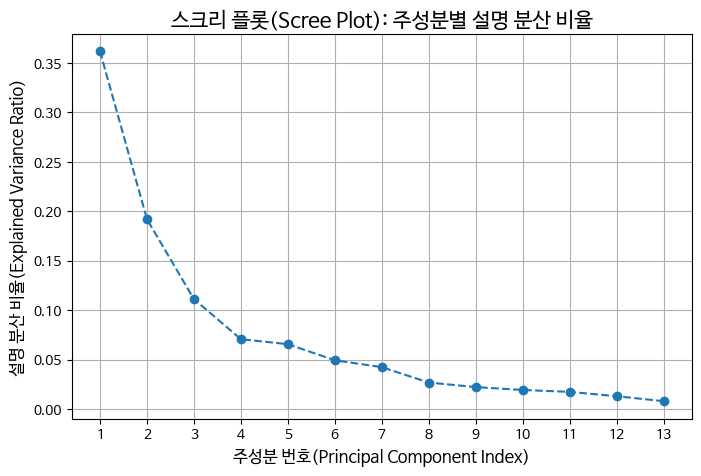

In [11]:
full_pca = PCA(n_components=X.shape[1], random_state=42)
full_pca.fit(X_scaled)

plt.figure(figsize=(8, 5)) # 그래프(figure)의 크기를 설정합니다.
plt.plot(range(1, X.shape[1] + 1), full_pca.explained_variance_ratio_, marker='o', linestyle='--') # 각 주성분(PC)의 설명 분산 비율을 선 그래프로 그립니다.
plt.title('스크리 플롯(Scree Plot): 주성분별 설명 분산 비율', fontsize=15) # 그래프 제목을 설정합니다.
plt.xlabel('주성분 번호(Principal Component Index)', fontsize=12) # x축 레이블을 설정합니다.
plt.ylabel('설명 분산 비율(Explained Variance Ratio)', fontsize=12) # y축 레이블을 설정합니다.
plt.grid(True) # 그리드를 표시합니다.
plt.xticks(range(1, X.shape[1] + 1)) # x축 틱(tick)을 설정합니다.
plt.show() # 그래프를 화면에 표시합니다.

## t-SNE

In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE 변환된 데이터 X_tsne 형태: ", X_tsne.shape)

t-SNE 변환된 데이터 X_tsne 형태:  (178, 2)


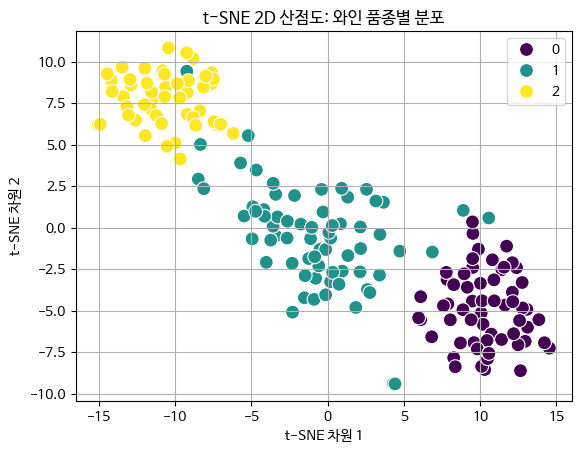

In [14]:
import seaborn as sns

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:,1], hue=y, palette="viridis", legend="full",
                s=100)
plt.title("t-SNE 2D 산점도: 와인 품종별 분포")
plt.xlabel("t-SNE 차원 1")
plt.ylabel("t-SNE 차원 2")
plt.grid(True)
plt.show()

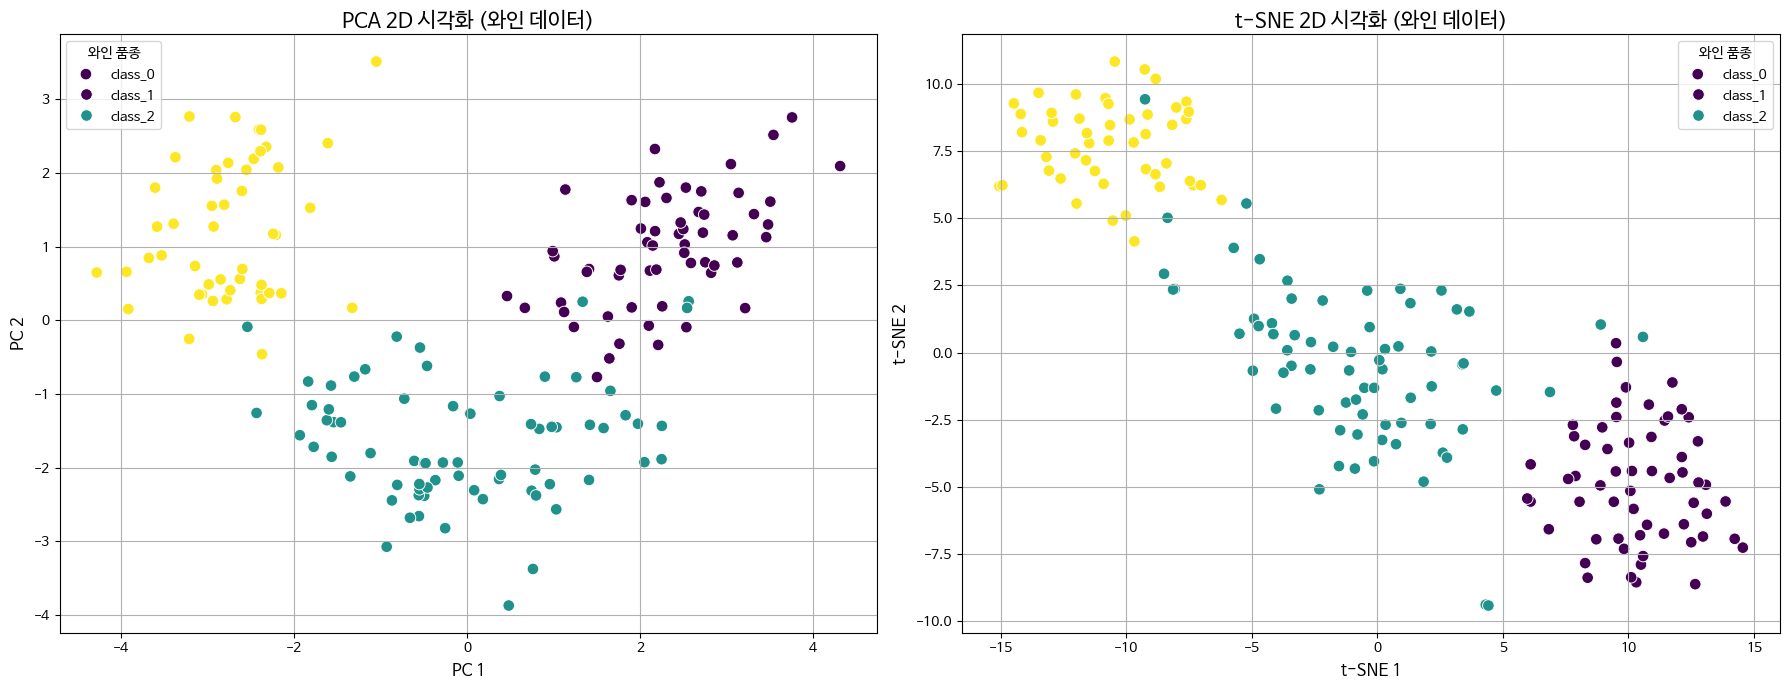

In [15]:
# 시각화
plt.figure(figsize=(18, 7))

# 1. PCA 결과
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', legend='full', s=70)
plt.title('PCA 2D 시각화 (와인 데이터)', fontsize=15)
plt.xlabel('PC 1', fontsize=12)
plt.ylabel('PC 2', fontsize=12)
plt.legend(title='와인 품종', labels=list(wine.target_names), loc='best')
plt.grid(True)

# 2. t-SNE 결과
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis', legend='full', s=70)
plt.title('t-SNE 2D 시각화 (와인 데이터)', fontsize=15)
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.legend(title='와인 품종', labels=list(wine.target_names), loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()

# 2차시: 군집화 실습(K-means, 계층적 군집화, DBSCAN)

## K-means 클러스터링

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_kmeans = pd.DataFrame({"cluster": clusters})
df_kmeans.head()

,cluster
0,2
1,2
2,2
3,2
4,2


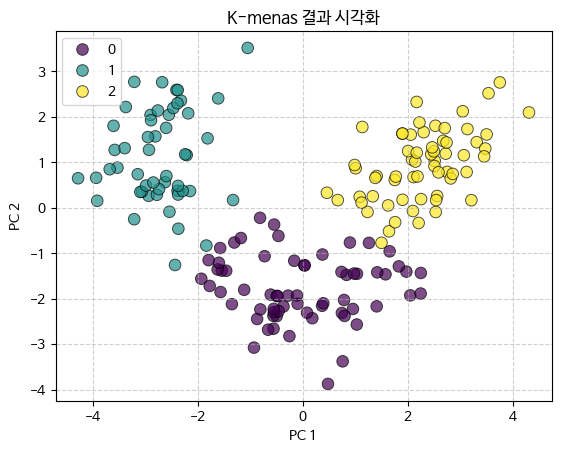

In [18]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1],
                hue=clusters, # 클러스터링 결과 확인
                palette="viridis", s=70, alpha=0.7,
                edgecolor="k")
plt.title("K-menas 결과 시각화")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [19]:
wcss = []
max_k = 10 # 확인할 K의 최대값을 10으로 설정

for i in range(1, max_k + 1):
  kmeans = KMeans(n_clusters=i, init="k-means++", max_iter=300, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

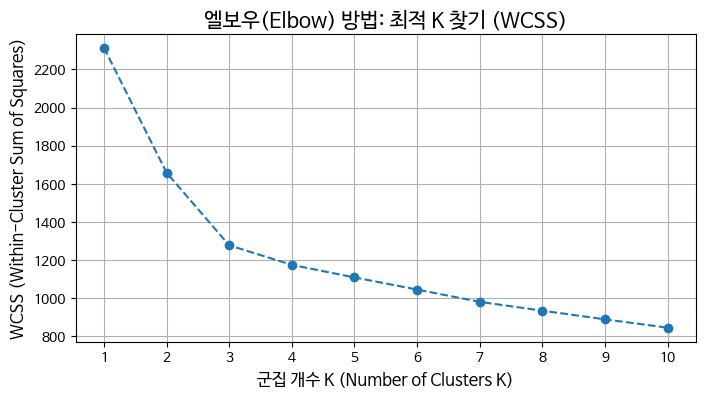

In [20]:
# WCSS 값을 시각화하여 엘보우(Elbow) 포인트를 찾습니다.
plt.figure(figsize=(8, 4)) # 그래프(figure)의 크기를 설정합니다.
plt.plot(range(1, max_k + 1), wcss, marker='o', linestyle='--') # K 값에 따른 WCSS 변화를 선 그래프로 그립니다.
plt.title('엘보우(Elbow) 방법: 최적 K 찾기 (WCSS)', fontsize=15) # 그래프 제목을 설정합니다.
plt.xlabel('군집 개수 K (Number of Clusters K)', fontsize=12) # x축 레이블을 설정합니다.
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12) # y축 레이블을 설정합니다.
plt.xticks(range(1, max_k + 1)) # x축 틱(tick)을 설정합니다.
plt.grid(True) # 그리드를 표시합니다.
plt.show() # 그래프를 화면에 표시합니다.
# → 그래프에서 WCSS 값이 급격히 감소하다가 완만해지는 지점(엘보우 포인트)이 최적의 K 값으로 고려될 수 있습니다.

In [30]:
from sklearn.metrics import silhouette_score

scores = []
k_range = range(2, 11)

for k in k_range:
  km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
  labels = km.fit_predict(X_scaled)
  scores.append(silhouette_score(X_scaled, labels))

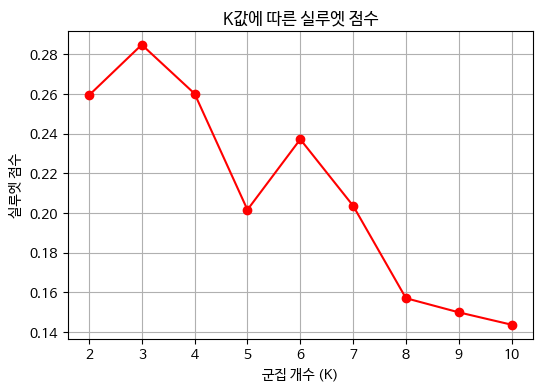

In [31]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, scores, 'ro-')
plt.title('K값에 따른 실루엣 점수')
plt.xlabel('군집 개수 (K)')
plt.ylabel('실루엣 점수')
plt.grid(True)
plt.show()

In [33]:
import numpy as np
best_k = k_range[np.argmax(scores)]
print(f"최적의 군집 개수(K): {best_k} (점수: {max(scores):.3f})")

최적의 군집 개수(K): 3 (점수: 0.285)


## 계층적 군집화

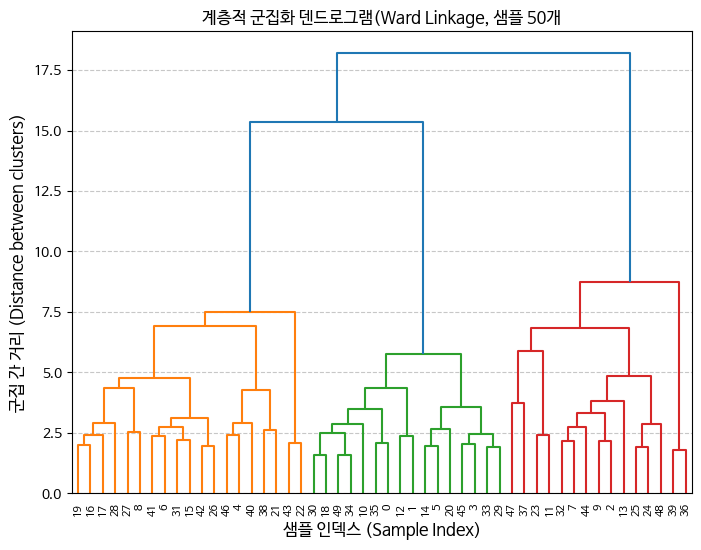

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], 50, replace=False)
X_sample = X_scaled[sample_indices]

linked_matrix = linkage(X_sample, method="ward")

plt.figure(figsize=(8, 6))
dendrogram(linked_matrix,
           orientation="top", distance_sort="descending",
           show_leaf_counts=True)
plt.title("계층적 군집화 덴드로그램(Ward Linkage, 샘플 50개")
plt.xlabel('샘플 인덱스 (Sample Index)', fontsize=12) # x축 레이블을 설정합니다.
plt.ylabel('군집 간 거리 (Distance between clusters)', fontsize=12) # y축 레이블을 설정합니다.
plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 그리드를 표시합니다.
plt.show() # 그래프를 화면에 표시합니다.

In [37]:
from sklearn.cluster import AgglomerativeClustering

k = 3
hierarchy_clustering = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X_scaled)

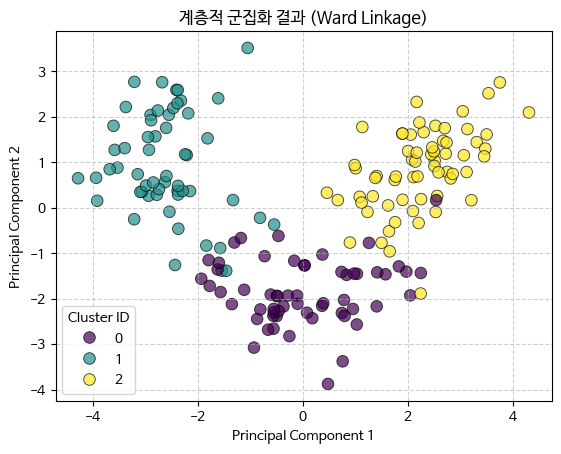

In [39]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=hierarchy_clustering.labels_, palette='viridis',
                s=70, alpha=0.7, edgecolor='k')
plt.title('계층적 군집화 결과 (Ward Linkage)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## DBSCAN

In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=4)
db_clusters = dbscan.fit_predict(X_scaled)

# 결과 확인
print(f"군집 개수: {len(set(db_clusters)) - (1 if -1 in db_clusters else 0)}")
print(f"노이즈 개수: {list(db_clusters).count(-1)}")

군집 개수: 0
노이즈 개수: 178


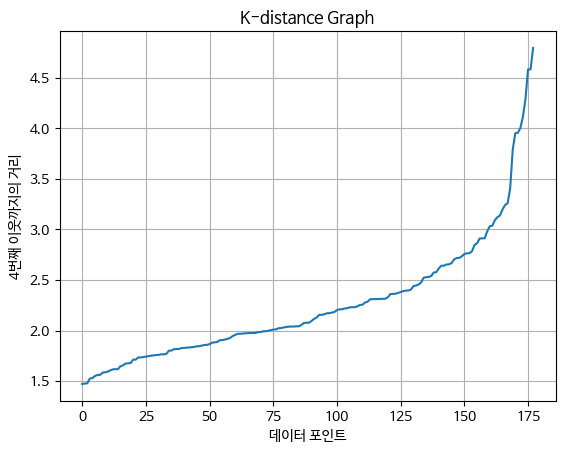

In [41]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 각 데이터에서 가장 가까운 k번째 이웃까지의 거리 계산
# min_samples를 4로 쓸 예정이면 k=4로 설정
k = 4
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# k번째 거리만 추출 후 정렬
distances = np.sort(distances[:, k-1])

plt.plot(distances)
plt.title('K-distance Graph')
plt.xlabel('데이터 포인트')
plt.ylabel(f'{k}번째 이웃까지의 거리')
plt.grid(True)
plt.show()
# → 그래프가 급격히 꺾이는 지점의 y값 = 적절한 eps

In [42]:
dbscan = DBSCAN(eps=2.0, min_samples=4)
db_clusters = dbscan.fit_predict(X_scaled)

print(f"군집 개수: {len(set(db_clusters)) - (1 if -1 in db_clusters else 0)}")
print(f"노이즈 개수: {list(db_clusters).count(-1)}")

군집 개수: 6
노이즈 개수: 66


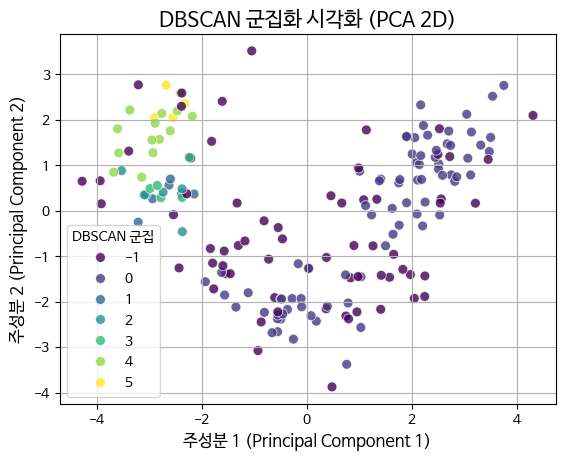

In [43]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan.labels_, palette='viridis',
                s=50, alpha=0.8, legend='full')

plt.title('DBSCAN 군집화 시각화 (PCA 2D)', fontsize=15) # 그래프 제목을 설정합니다.
plt.xlabel('주성분 1 (Principal Component 1)', fontsize=12) # x축 레이블을 설정합니다.
plt.ylabel('주성분 2 (Principal Component 2)', fontsize=12) # y축 레이블을 설정합니다.
plt.legend(title='DBSCAN 군집', loc='best') # 범례를 설정합니다.
plt.grid(True) # 그리드를 표시합니다.
plt.show() # 그래프를 화면에 표시합니다.

## 비교

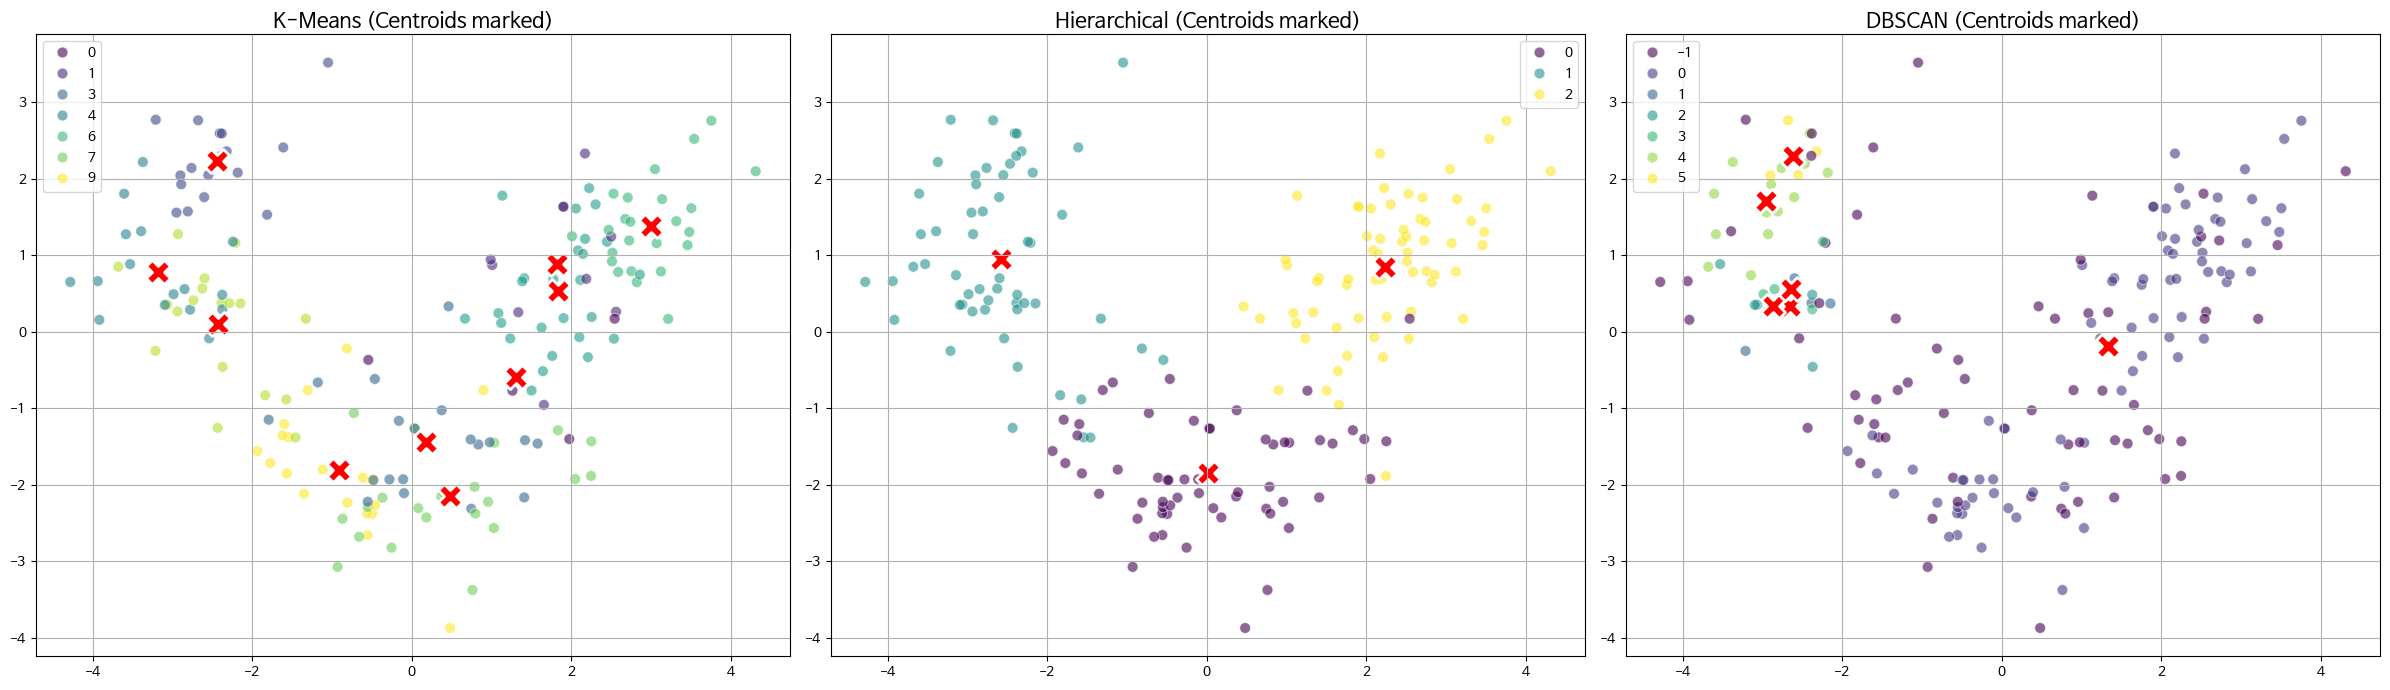

In [45]:
# 모델별 레이블 리스트
labels_list = [kmeans.labels_, hierarchy_clustering.labels_, dbscan.labels_]
titles = ['K-Means', 'Hierarchical', 'DBSCAN']

plt.figure(figsize=(24, 7))

for i, (labels, title) in enumerate(zip(labels_list, titles)):
    plt.subplot(1, 3, i + 1)

    # 산점도 그리기
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='viridis', s=60, alpha=0.6)

    # 각 군집별 중심점(평균) 계산 및 표시
    # 노이즈(-1) 제외
    unique_labels = [l for l in np.unique(labels) if l != -1]
    for label in unique_labels:
        # 해당 군집에 속한 포인트들의 PCA 좌표 평균 계산
        cluster_points = X_pca[labels == label]
        centroid = cluster_points.mean(axis=0)

        # 중심점 그리기
        plt.scatter(centroid[0], centroid[1], marker='X', s=300,
                    color='red', edgecolor='white', linewidth=2, label=f'Centroid {label}')

    plt.title(f'{title} (Centroids marked)', fontsize=15)
    plt.grid(True)

plt.tight_layout()
plt.show()